# 04 - 循环神经网络 RNN

> 配套教程：`04_deep_learning/04_rnn.py`

RNN 用于处理序列数据，例如文本、时间序列、语音。它的核心思想是隐藏状态：当前输出不仅依赖当前输入，也依赖之前积累的记忆。

## 本 Notebook 概览

| 章节 | 内容 | 关键概念 |
|------|------|----------|
| 1 | RNN 直觉 | 序列、隐藏状态、参数共享 |
| 2 | 从零实现 RNN | 时间步循环、隐藏状态更新 |
| 3 | 梯度消失/爆炸 | 长距离依赖、连乘效应 |
| 4 | LSTM | 遗忘门、输入门、输出门、细胞状态 |
| 5 | 正弦波预测 | PyTorch LSTM、序列回归 |
| 6 | 文本分类 | Embedding、LSTM、分类头 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager


def configure_chinese_font():
    preferred_fonts = [
        "Noto Sans CJK SC", "Noto Sans CJK JP", "Source Han Sans SC",
        "WenQuanYi Zen Hei", "WenQuanYi Micro Hei", "SimHei",
        "Microsoft YaHei", "PingFang SC", "Arial Unicode MS",
    ]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in preferred_fonts:
        if font_name in available_fonts:
            plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
            plt.rcParams["font.family"] = "sans-serif"
            print(f"Matplotlib 中文字体: {font_name}")
            return font_name
    print("未检测到可用中文字体，中文图表可能显示为方框。")
    return None


CHINESE_FONT = configure_chinese_font()
plt.rcParams["axes.unicode_minus"] = False
np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)

import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)
print("第四章 4.4：循环神经网络 (RNN)")
print("PyTorch 版本:", torch.__version__)

Matplotlib 中文字体: Noto Sans CJK JP
第四章 4.4：循环神经网络 (RNN)
PyTorch 版本: 2.11.0+cpu


## 1. RNN 的直觉与结构

全连接网络和 CNN 通常处理固定大小输入，但很多数据天然是序列：

- 文本：词的顺序会改变意思。
- 时间序列：今天的值和昨天、前天有关。
- 语音：每个采样点和上下文有关。

RNN 在每个时间步维护隐藏状态：

$$h_t=f(W_xx_t+W_hh_{t-1}+b)$$

$h_t$ 像“记忆”，包含了当前输入和过去信息。

## 2. 从零实现 RNN 前向传播

RNN 的关键是时间循环：同一组权重在每个时间步重复使用。下面实现一个只做前向传播的 RNN，用来理解形状和隐藏状态更新。

In [2]:
class SimpleRNN:
    def __init__(self, input_size, hidden_size, output_size):
        self.hidden_size = hidden_size
        self.W_xh = np.random.randn(input_size, hidden_size) * 0.01
        self.W_hh = np.random.randn(hidden_size, hidden_size) * 0.01
        self.b_h = np.zeros((1, hidden_size))
        self.W_hy = np.random.randn(hidden_size, output_size) * 0.01
        self.b_y = np.zeros((1, output_size))

    def forward(self, X_sequence):
        seq_len = X_sequence.shape[0]
        h = np.zeros((1, self.hidden_size))
        all_h, all_y = [], []
        for t in range(seq_len):
            x_t = X_sequence[t:t+1]
            h = np.tanh(x_t @ self.W_xh + h @ self.W_hh + self.b_h)
            y_t = h @ self.W_hy + self.b_y
            all_h.append(h.copy())
            all_y.append(y_t.copy())
        return np.vstack(all_y), np.vstack(all_h)


rnn = SimpleRNN(input_size=3, hidden_size=5, output_size=2)
sequence = np.random.randn(4, 3)
outputs, hidden_states = rnn.forward(sequence)
print("输入序列形状:", sequence.shape)
print("输出形状:", outputs.shape)
print("隐藏状态形状:", hidden_states.shape)
print("最后一步隐藏状态:", hidden_states[-1].round(4))

输入序列形状: (4, 3)
输出形状: (4, 2)
隐藏状态形状: (4, 5)
最后一步隐藏状态: [ 0.0069 -0.0083  0.0023  0.0211 -0.0017]


## 3. 梯度消失/爆炸问题

RNN 展开后像一个很深的网络，时间步越长，反向传播路径越长。梯度会不断乘以相似的矩阵和激活函数导数：

- 如果连乘因子小于 1，梯度会指数级衰减。
- 如果连乘因子大于 1，梯度会指数级爆炸。

梯度消失会导致模型难以学习长距离依赖；梯度爆炸会导致训练不稳定。常见缓解方法包括 LSTM/GRU、梯度裁剪、Transformer。

In [3]:
print("--- 梯度消失演示 ---")
W = np.array([[0.5, 0], [0, 0.5]])
gradient = np.ones(2)
for t in range(10):
    gradient = W @ gradient
    if t in [0, 2, 5, 9]:
        print(f"经过 {t+1} 步: 梯度范数 = {np.linalg.norm(gradient):.8f}")

print("\n--- 梯度爆炸演示 ---")
W2 = np.array([[1.5, 0], [0, 1.5]])
gradient2 = np.ones(2)
for t in range(10):
    gradient2 = W2 @ gradient2
    if t in [0, 2, 5, 9]:
        print(f"经过 {t+1} 步: 梯度范数 = {np.linalg.norm(gradient2):.4f}")

--- 梯度消失演示 ---
经过 1 步: 梯度范数 = 0.70710678
经过 3 步: 梯度范数 = 0.17677670
经过 6 步: 梯度范数 = 0.02209709
经过 10 步: 梯度范数 = 0.00138107

--- 梯度爆炸演示 ---
经过 1 步: 梯度范数 = 2.1213
经过 3 步: 梯度范数 = 4.7730
经过 6 步: 梯度范数 = 16.1088
经过 10 步: 梯度范数 = 81.5507


## 4. LSTM：长短期记忆网络

LSTM 引入细胞状态 $C_t$，像一条信息高速通道，让重要信息能更稳定地跨时间传递。

三个门：

- **遗忘门**：决定旧信息保留多少。
- **输入门**：决定新信息写入多少。
- **输出门**：决定当前隐藏状态输出什么。

状态更新：

$$C_t=f_t\odot C_{t-1}+i_t\odot \tilde C_t$$

$$h_t=o_t\odot \tanh(C_t)$$

可以把 $C_t$ 理解为笔记本，门机制决定擦掉什么、写入什么、读出什么。

## 5. PyTorch LSTM：正弦波预测

任务：给定正弦波前 20 个时间步，预测第 21 个值。

输入形状是 `(batch, seq_len, input_size)`，因为我们设置 `batch_first=True`。这里每个时间步只有一个特征，所以 `input_size=1`。

In [4]:
def create_sine_data(seq_length=20, n_samples=1000):
    X, y = [], []
    t = np.linspace(0, 100, n_samples + seq_length)
    data = np.sin(t)
    for i in range(n_samples):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    X = np.array(X).reshape(-1, seq_length, 1)
    y = np.array(y).reshape(-1, 1)
    return X, y


X, y = create_sine_data(seq_length=20, n_samples=800)
X_train = torch.FloatTensor(X[:600])
y_train = torch.FloatTensor(y[:600])
X_test = torch.FloatTensor(X[600:])
y_test = torch.FloatTensor(y[600:])
print("训练集:", X_train.shape, "->", y_train.shape)
print("测试集:", X_test.shape, "->", y_test.shape)

训练集: torch.Size([600, 20, 1]) -> torch.Size([600, 1])
测试集: torch.Size([200, 20, 1]) -> torch.Size([200, 1])


In [5]:
class LSTMPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        return self.fc(last_output)


torch.manual_seed(42)
model = LSTMPredictor(input_size=1, hidden_size=32)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
print(model)

LSTMPredictor(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [6]:
print("--- 训练 ---")
n_epochs = 40
batch_size = 32
for epoch in range(n_epochs):
    model.train()
    indices = np.random.permutation(len(X_train))
    total_loss = 0
    n_batches = 0
    for i in range(0, len(X_train), batch_size):
        batch_idx = indices[i:i+batch_size]
        batch_X = X_train[batch_idx]
        batch_y = y_train[batch_idx]
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    if epoch % 10 == 0 or epoch == n_epochs - 1:
        model.eval()
        with torch.no_grad():
            test_pred = model(X_test)
            test_loss = criterion(test_pred, y_test)
        print(f"Epoch {epoch:3d}: train_loss={total_loss/n_batches:.6f}, test_loss={test_loss:.6f}")

model.eval()
with torch.no_grad():
    predictions = model(X_test).numpy()
mse = np.mean((predictions - y_test.numpy()) ** 2)
print("最终 MSE:", round(float(mse), 6))
for i in range(5):
    print(f"预测: {predictions[i][0]:7.4f}, 真实: {y_test[i].item():7.4f}")
assert mse < 0.02
print("✓ LSTM 成功学习正弦波预测")

--- 训练 ---
Epoch   0: train_loss=0.142019, test_loss=0.005453
Epoch  10: train_loss=0.000008, test_loss=0.000006
Epoch  20: train_loss=0.000005, test_loss=0.000004
Epoch  30: train_loss=0.000003, test_loss=0.000002
Epoch  39: train_loss=0.000002, test_loss=0.000003
最终 MSE: 3e-06
预测:  0.2962, 真实:  0.2992
预测:  0.4109, 真实:  0.4132
预测:  0.5198, 真实:  0.5210
预测:  0.6207, 真实:  0.6211
预测:  0.7120, 真实:  0.7119
✓ LSTM 成功学习正弦波预测


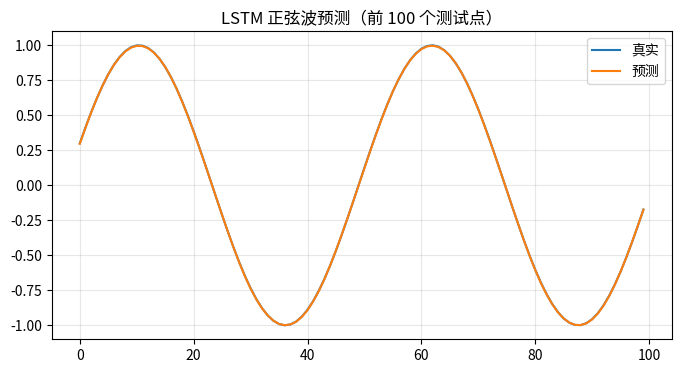

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(y_test.numpy()[:100], label="真实")
plt.plot(predictions[:100], label="预测")
plt.title("LSTM 正弦波预测（前 100 个测试点）")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. 文本分类示例

文本进入 RNN 前通常要经过：

1. 分词。
2. 构建词表。
3. 词转索引。
4. Embedding 把索引转成向量。
5. LSTM 处理向量序列。
6. 全连接层分类。

下面用随机索引模拟文本，重点看模型结构和训练流程。

In [8]:
vocab_size = 100
embed_dim = 16
hidden_dim = 32
max_len = 10
n_classes = 2


class TextClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (h_n, _) = self.lstm(embedded)
        last_hidden = h_n.squeeze(0)
        return self.fc(last_hidden)


torch.manual_seed(42)
X_text_train = torch.randint(0, vocab_size, (500, max_len))
y_text_train = torch.randint(0, n_classes, (500,))
X_text_test = torch.randint(0, vocab_size, (100, max_len))
y_text_test = torch.randint(0, n_classes, (100,))

text_model = TextClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(text_model.parameters(), lr=0.01)

for epoch in range(20):
    outputs = text_model(X_text_train)
    loss = criterion(outputs, y_text_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

text_model.eval()
with torch.no_grad():
    test_outputs = text_model(X_text_test)
    predicted = test_outputs.argmax(dim=1)
    acc = (predicted == y_text_test).float().mean()
print("文本分类准确率:", round(acc.item(), 4))
print("随机数据准确率约 50% 是正常的；这里验证的是结构和流程。")

文本分类准确率: 0.56
随机数据准确率约 50% 是正常的；这里验证的是结构和流程。


## 7. 总结与练习

关键要点：

1. RNN 通过隐藏状态处理序列。
2. 普通 RNN 容易梯度消失或爆炸。
3. LSTM 用门机制和细胞状态改善长距离依赖。
4. 文本常用 Embedding -> LSTM -> Linear 的结构。
5. 对长序列和大规模语言建模，Transformer 已经成为主流。

**练习**：改变 `seq_length`、`hidden_size`、`n_epochs`，观察正弦波预测效果和训练时间。

## 8. 深入理解：隐藏状态是“压缩后的历史”

RNN 每一步只保留一个隐藏状态 $h_t$。它必须把过去所有有用信息压缩到固定长度向量里。

这带来两个结果：

- 对短序列，RNN/LSTM 通常很自然。
- 对很长序列，固定长度隐藏状态可能成为瓶颈，早期信息容易丢失。

LSTM 通过细胞状态和门机制改善了这个问题，但并没有彻底消除长序列建模难题。这也是后来 Attention 和 Transformer 变得重要的原因。

## 9. RNN、LSTM、GRU、Transformer 怎么选

| 模型 | 适合场景 | 特点 |
|------|----------|------|
| RNN | 教学、小型短序列 | 结构简单，但长依赖弱 |
| LSTM | 时间序列、较长依赖 | 门机制稳定，经典可靠 |
| GRU | 类似 LSTM | 参数更少，速度更快 |
| Transformer | 长文本、大规模序列 | 并行能力强，现代 NLP 主流 |

学习路径建议：先理解 RNN 的隐藏状态，再理解 LSTM 的门，最后学习 Attention 如何直接建立任意位置之间的联系。

## 10. 序列任务调试清单

1. **确认输入形状**：`batch_first=True` 时是 `(batch, seq_len, features)`。
2. **确认标签含义**：是每个时间步一个标签，还是整个序列一个标签？
3. **检查是否需要最后一步输出**：分类常用最后隐藏状态，序列标注需要每个时间步输出。
4. **使用梯度裁剪**：长序列训练不稳定时，`clip_grad_norm_` 很有用。
5. **从简单模式开始**：先让模型拟合正弦波这类简单序列，再上真实任务。

序列建模最重要的是明确“输入序列是什么、目标是什么、模型应该在每个时间步输出还是只在最后输出”。

## 11. 时间序列预测和文本分类的区别

这两个任务都使用序列模型，但目标不一样。

时间序列预测通常是“看过去若干步，预测下一步或未来若干步”。输入和输出都与时间顺序强相关，例如正弦波、股票价格、传感器读数。

文本分类通常是“读完整个句子或文档，给出一个整体标签”。模型不一定要在每个词后输出分类结果，而是可以用最后隐藏状态作为整句摘要。

所以做序列任务前，第一步不是选模型，而是明确目标：你需要每个时间步的输出，还是整个序列的一个输出？这个决定会影响标签形状、损失函数和模型 forward 的写法。

## 12. 为什么梯度会消失或爆炸

RNN 在时间维度上反复使用同一组参数。反向传播时，梯度要沿着很多时间步一层层乘回去。

如果连续相乘的数大多小于 1，梯度会越来越小，早期时间步几乎学不到东西，这就是梯度消失。

如果连续相乘的数大多大于 1，梯度会越来越大，参数更新变得不稳定，这就是梯度爆炸。

LSTM 的门机制让信息可以沿细胞状态更稳定地传递；梯度裁剪则是在训练时限制梯度范数，避免一次更新过猛。二者分别从结构和训练技巧两个角度缓解问题。

## 13. 学完本节后应该能做到什么

建议你确认自己能回答：

- RNN 的隐藏状态为什么可以看作历史信息摘要？
- `batch_first=True` 时输入张量三个维度分别表示什么？
- 序列分类为什么常取最后一个时间步的隐藏状态？
- LSTM 的门机制大致解决了普通 RNN 的什么问题？
- 什么时候应该考虑 Transformer 而不是 RNN/LSTM？

这些问题能帮助你把代码和任务建模联系起来。序列模型最怕只记 API，不理解输入、隐藏状态和目标之间的关系。